In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load and filter: create a dedicated episode_df
df = pd.read_csv("dataset/lyrics_annotated.csv")

In [6]:
EPISODE_THRESHOLDS = {
    "high": 0.66,
    "medium": 0.45,
    "low": 0.33
}

def map_to_episode(valence, arousal, dominance, thresholds=None):
    """
    Maps VAD values to one of 5 Episode Model categories based on heuristics.
    """
    if thresholds is None:
        thresholds = {
            "high": 0.66,
            "medium": 0.45,
            "low": 0.33
        }

    if valence is None or arousal is None or dominance is None:
        return None

    V, A, D = valence, arousal, dominance

    # High valence + low arousal = EDR
    if V > thresholds["medium"] and A < thresholds["medium"]:
        return "EDR"
    
    # Medium all around = CB
    if thresholds["low"] < V < thresholds["high"] and thresholds["low"] < A < thresholds["high"] and thresholds["low"] < D < thresholds["high"]:
        return "CB"

    # High all = FM
    if V > thresholds["high"] and A > thresholds["high"] and D > thresholds["high"]:
        return "FM"

    # Low valence + high arousal = PEP
    if V < thresholds["medium"] and A > thresholds["medium"] and D < thresholds["medium"]:
        return "PEP"

    # Moderate valence + high arousal + low dominance = AIA
    if thresholds["low"] < V < thresholds["high"] and A > thresholds["medium"] and D < thresholds["medium"]:
        return "AIA"

    return "Unclassified"

# Apply rule-based episode mapping to your DataFrame
df["episode"] = df.apply(
    lambda row: map_to_episode(row["valence"], row["arousal"], row["dominance"]),
    axis=1
)

# Summary counts
episode_counts = df["episode"].value_counts()
print("\n🎭 Episode Distribution:")
print(episode_counts)


🎭 Episode Distribution:
episode
EDR             892444
CB              645471
Unclassified    505085
PEP              31908
AIA               4036
FM                 566
Name: count, dtype: int64


/Users/alunx/repos/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



📊 Classification Report:
              precision    recall  f1-score   support

         AIA       0.90      0.79      0.84       807
          CB       0.87      0.93      0.90    129094
         EDR       0.91      0.95      0.93    178489
          FM       0.89      0.60      0.72       113
         PEP       0.87      0.83      0.85      6382
Unclassified       0.99      0.27      0.42     21110

    accuracy                           0.90    335995
   macro avg       0.91      0.73      0.78    335995
weighted avg       0.90      0.90      0.89    335995



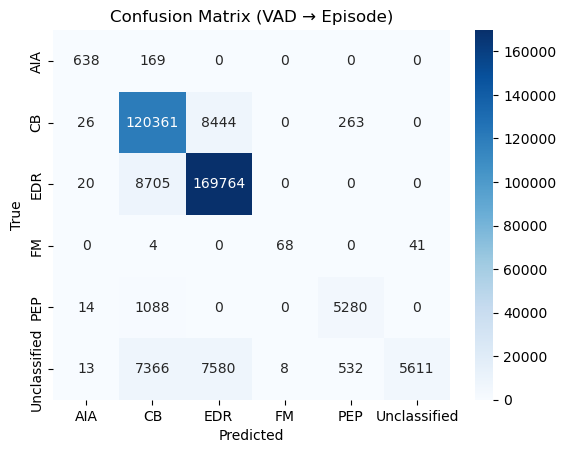

In [10]:

# Extract VAD features and labels
df = df.dropna(subset=["valence", "arousal", "dominance"])
X = df[["valence", "arousal", "dominance"]]
y = df["episode"]

# Standardize VAD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Train logistic regression classifier
clf = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs")
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap="Blues")
plt.title("Confusion Matrix (VAD → Episode)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()